In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# LOAD DATASET
# ==========================================================
import pandas as pd
# Read CSV file from Google Drive
file_path = "/content/drive/MyDrive/Colab Notebooks/Models Data/house_prices_practice.csv"
df = pd.read_csv(file_path)

In [3]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [6]:
df.shape

(299, 10)

In [9]:
X= df.drop(["Id","SalePrice"],axis=1)
y=df["SalePrice"]

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)


In [14]:
from xgboost import XGBRegressor

xgb_model= XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=4,random_state=42)
xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
y_pred = xgb_model.predict(X_test)
print(y_pred)

[204803.75  191405.67  283501.72  230024.16  351268.78  260019.22
 205681.    210985.6   172533.77  155557.95  182409.61  258819.27
 184021.27  263748.2   286627.25  294399.75  292861.16  197039.95
 311008.66  276182.97  348733.5   311694.84  321595.3   252085.14
 335094.97  215773.7   162845.78  216672.6   148809.17  182162.48
 386578.5   130602.984 140005.02  201124.56  191780.64  341528.75
 174209.42  206339.02  216841.95  316336.25  292896.06  184385.03
 212389.77  319734.3   237595.8   185728.95  189582.98  164921.16
 290750.53  328566.56  301943.9   167623.17  180829.16  286756.47
 151138.81  178437.73  273021.3   147821.03  201419.78  241358.52
 140724.73  238632.08  342314.44  370872.75  361062.75  302802.
 238862.27  132764.98  332965.25  330515.72  231429.69  183817.62
 222734.02  205110.06  279244.44  390600.12  275267.16  300783.
 313540.78  259158.88  342943.88  131370.89  162288.6   382909.97
 290031.62  231277.44  165687.08  274079.34  164576.33  309104.44 ]


In [18]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE ::",mae)
print("MSE ::",mse)
print("R2  ::",r2)


MAE :: 17856.822265625
MSE :: 591684928.0
R2  :: 0.9036561250686646


In [19]:
comparison =pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

print(comparison.head(10))

     Actual      Predicted
281  225589  204803.750000
265  181535  191405.671875
164  290763  283501.718750
9    211664  230024.156250
77   353246  351268.781250
278  265591  260019.218750
93   215533  205681.000000
109  209025  210985.593750
5    213952  172533.765625
173  153184  155557.953125


In [23]:
sample_house =  [[9,1667,0,988,1958,2,1,14553]]
predicted_price = xgb_model.predict(sample_house)

print(round(predicted_price[0],2))

208082.81


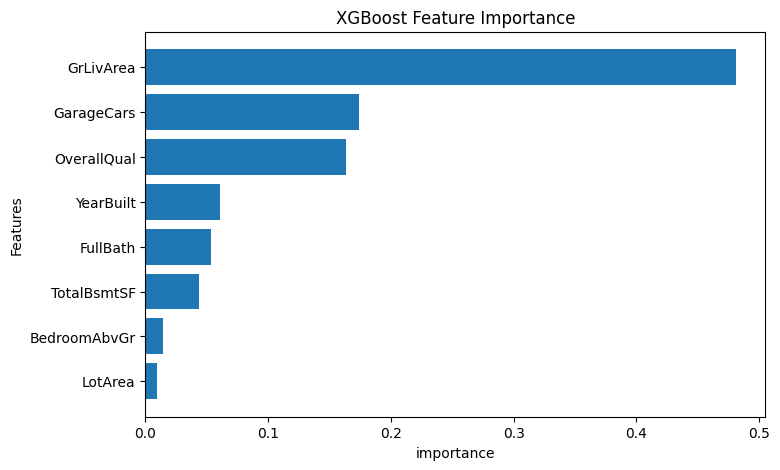

In [25]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":xgb_model.feature_importances_
})
importance = importance.sort_values(by="Importance",ascending=True)
plt.figure(figsize=(8,5))
plt.barh(importance["Feature"],importance["Importance"])
plt.xlabel("importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.show()